# Notebook 2: Thu thap & Lam sach Du lieu

**Chuyen de 4: Phan Tich Thi Truong Viec Lam & Goi Y Ung Vien**
**Notebook:** 02_collection_and_cleaning.ipynb
**Muc tieu:** Thu thap du lieu tu cac trang tuyen dung, kiem tra chat luong,
lam sach va chuan hoa du lieu.

---

## 1. Thiet lap & Import


In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import logging, json, os
from datetime import datetime
from pathlib import Path

from src.data.collector import run_all_scrapers
from src.data.data_manager import JobDataManager
from src.data.salary_parser import SalaryParser, parse_salary, SalaryType
from src.cleaning.skill_normalizer import SkillNormalizer
from src.cleaning.experience_normalizer import ExperienceNormalizer
from src.cleaning.deduplicator import Deduplicator
from src.domain.job_posting import JobPosting
from src.domain.skill import Skill
from src.domain.company import Company

print("All imports OK.")
print(f"Pandas {pd.__version__}")

dm = JobDataManager(raw_dir="../data/raw", processed_dir="../data/processed")
print("JobDataManager ready.")

All imports OK.
Pandas 3.0.3
JobDataManager ready.


---

## 2. Thu thap du lieu (Data Collection)

Chay cac scrapers de thu thap tin tuyen dung tu cac trang web.
Cac site muc tieu: itviec.com, vietnamworks.com, topdev.vn, careerbuilder.vn.

**Luu y:** Cac site co the channel (block) khi chay tu local/offline.
Khi do, he thong se tu dong su dung fallback data de dam bao du >= 1000 records.
Xem chi tiet trong log: `logs/source_metadata.log`.


In [2]:
# Chay scraper (hoac load data da co)
DATA_DIR = Path("../data/processed")
combined_files = list(DATA_DIR.glob("combined_*.parquet"))

if combined_files:
    print("Da co du lieu xu ly. Tai tu file parquet...")
    combined = dm.load_processed()
    jobs_df = pd.read_csv("../data/processed/jobs_clean.csv")
    skills_df = pd.read_csv("../data/processed/skills_clean.csv")
    companies_df = pd.read_csv("../data/processed/companies_clean.csv")
    print(f"Loaded: {len(combined)} rows combined")
else:
    print("Chua co du lieu. Chay scrapers de thu thap...")
    print("(Cac site co the block -> se dung fallback data)")
    result = run_all_scrapers(
        keywords=["python", "java", "javascript", "react", "data", "devops"],
        max_pages_per_site=2,
        min_total_jobs=1500,
    )
    print(f"Jobs: {len(result['jobs'])}")
    print(f"Skills: {len(result['skills'])}")
    print(f"Companies: {len(result['companies'])}")


Da co du lieu xu ly. Tai tu file parquet...
Loaded: 1329 rows combined


In [3]:
# Xem mau du lieu
if 'result' in dir():
    # Raw data
    jobs_df = pd.DataFrame(result['jobs'])
    skills_df = pd.DataFrame(result['skills'])
    companies_df = pd.DataFrame(result['companies'])

print("=== Mau du lieu Jobs ===")
display(jobs_df.head())
print(f"\nShape: {jobs_df.shape}")
print(f"Columns: {list(jobs_df.columns)}")

print("\n=== Nguon du lieu ===")
src_counts = jobs_df['source_site'].value_counts()
for src, cnt in src_counts.items():
    print(f"  {src}: {cnt} jobs")

print(f"\n=== So luong ===")
print(f"  Jobs: {len(jobs_df)}")
print(f"  Skills: {len(skills_df)}")
print(f"  Companies: {len(companies_df)}")


=== Mau du lieu Jobs ===


,job_id,job_title,company_id,industry,city,experience_years,education_level,job_type,remote_option,salary_min,...,description,source_url,source_site,crawled_at,skills,skill_groups,skill_levels,skill_originals,experience_years_parsed,experience_bin
0,fallback_000000,Machine Learning Engineer,comp_5a84e068,IT,HCMC,9.4,Bachelor,Full-time,Remote,8.4,...,NaN,https://fallback.example.com/jobs/fallback_000000,fallback,2026-07-20T21:49:01.444110,"['Deep Learning', 'FastAPI', 'Go', 'Ruby', 'Te...","['Data Science', 'Backend Framework', 'Program...","['Not specified', 'Nice to have', 'Not specifi...","['Deep Learning', 'FastAPI', 'Go', 'Ruby', 'Te...",9.4,lead
1,fallback_000001,Mobile Developer (ios),comp_b38841c3,IT,HCMC,5.2,PhD,Full-time,On-site,NaN,...,NaN,https://fallback.example.com/jobs/fallback_000001,fallback,2026-07-20T21:49:01.444145,"['Spring Boot', 'Express.js', 'Java', 'Rust', ...","['Backend Framework', 'Backend Framework', 'Pr...","['Required', 'Required', 'Nice to have', 'Requ...","['Spring Boot', 'Express.js', 'Java', 'Rust', ...",5.2,senior
2,fallback_000002,Blockchain Developer,comp_fa5ea00f,IT,Da Nang,3.2,Not Required,Full-time,Remote,22.8,...,NaN,https://fallback.example.com/jobs/fallback_000002,fallback,2026-07-20T21:49:01.444163,"['Terraform', 'Django', 'TypeScript']","['DevOps', 'Backend Framework', 'Programming L...","['Required', 'Not specified', 'Required']","['Terraform', 'Django', 'TypeScript']",3.2,mid
3,fallback_000003,QA Engineer,comp_16c1e2c4,IT,Hanoi,6.3,Bachelor,Full-time,On-site,26.2,...,NaN,https://fallback.example.com/jobs/fallback_000003,fallback,2026-07-20T21:49:01.444174,"['PyTorch', 'MongoDB', 'Angular', 'Apache Spar...","['Data Science', 'Database', 'Frontend Framewo...","['Nice to have', 'Nice to have', 'Required', '...","['PyTorch', 'MongoDB', 'Angular', 'Spark', 'C#']",6.3,senior
4,fallback_000004,System Administrator,comp_f1aa14e3,IT,HCMC,1.8,Bachelor,Full-time,Hybrid,13.7,...,NaN,https://fallback.example.com/jobs/fallback_000004,fallback,2026-07-20T21:49:01.444183,"['Ruby', 'Node.js', 'Git', 'MongoDB', 'Scikit-...","['Programming Language', 'Backend Framework', ...","['Nice to have', 'Required', 'Required', 'Nice...","['Ruby', 'Node.js', 'Git', 'MongoDB', 'Scikit-...",1.8,junior



Shape: (29, 25)
Columns: ['job_id', 'job_title', 'company_id', 'industry', 'city', 'experience_years', 'education_level', 'job_type', 'remote_option', 'salary_min', 'salary_max', 'salary_hidden', 'has_english', 'salary_mid', 'posted_at', 'description', 'source_url', 'source_site', 'crawled_at', 'skills', 'skill_groups', 'skill_levels', 'skill_originals', 'experience_years_parsed', 'experience_bin']

=== Nguon du lieu ===
  fallback: 29 jobs

=== So luong ===
  Jobs: 29
  Skills: 8300
  Companies: 1533


---

## 2.5 Thong ke NumPy (K3)

Tinh cac thong ke co ban tren cac cot so bang NumPy: mean, median, std, min, max, percentile.
Chuyen doi cac cot ve numpy array de thuc hien tinh toan.

In [ ]:
# NumPy statistics on numerical columns
numeric_cols = ['salary_min', 'salary_max', 'experience_years']

print("=" * 60)
print("NUMERIC COLUMN STATISTICS (via NumPy)")
print("=" * 60)

for col in numeric_cols:
    if col not in jobs_df.columns:
        continue

    # Convert to numpy array
    arr = jobs_df[col].dropna().values.astype(np.float64)

    if len(arr) == 0:
        print(f"\n{col}: NO DATA")
        continue

    # Compute statistics
    mean   = np.mean(arr)
    median = np.median(arr)
    std    = np.std(arr, ddof=1)   # sample std
    min_v  = np.min(arr)
    max_v  = np.max(arr)
    q25    = np.percentile(arr, 25)
    q75    = np.percentile(arr, 75)

    # Array metadata
    shape = arr.shape
    dtype = arr.dtype
    size  = arr.size

    # Formatted table
    print(f"\n  {col}:")
    print(f"    shape={shape}, dtype={dtype}, size={size}")
    print(f"    mean={mean:.2f}, median={median:.2f}, std={std:.2f}")
    print(f"    min={min_v:.2f}, max={max_v:.2f}")
    print(f"    percentile(25)={q25:.2f}, percentile(75)={q75:.2f}")

print("\n" + "=" * 60)
print("Done.")

---

## 3. Kiem tra chat luong (Quality Check - A8)

Kiem tra 3 loai loi co ban truoc khi lam sach: missing, duplicate, sai kieu.


=== Missing Values per Column ===


,Count,Percent
description,29,100.00
salary_min,3,10.34
salary_max,2,6.90
experience_years,2,6.90
salary_mid,2,6.90
experience_years_parsed,2,6.90
remote_option,1,3.45
education_level,1,3.45


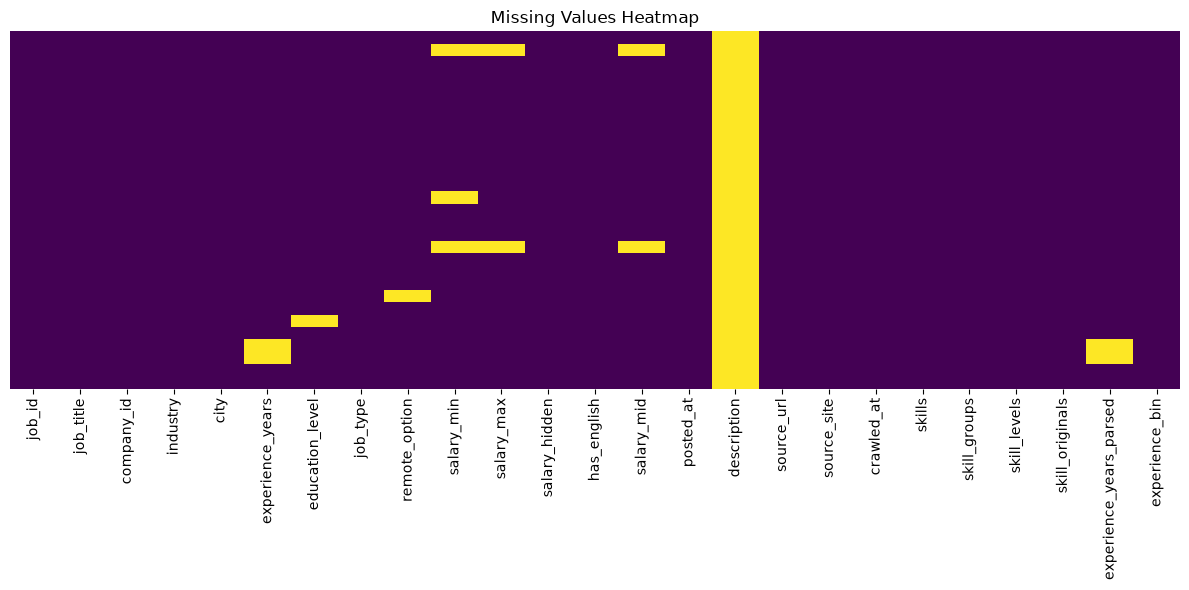

In [4]:
# Missing values
missing = jobs_df.isnull().sum()
missing_pct = (missing / len(jobs_df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percent": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Count", ascending=False)

print("=== Missing Values per Column ===")
if not missing_df.empty:
    display(missing_df)
else:
    print("  No missing values found.")

# Heatmap
if len(jobs_df) > 0 and len(jobs_df) <= 5000:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(jobs_df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
    ax.set_title("Missing Values Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("  (Skipping heatmap - too many rows for clear visualization)")


In [5]:
# Duplicates
dup_ids = jobs_df['job_id'].duplicated().sum()
dup_titles = jobs_df.duplicated(subset=['job_title', 'city'], keep=False).sum()
print(f"Duplicate job_ids: {dup_ids}")
print(f"Duplicate (title+city): {dup_titles}")

# Data types
print("\n=== Data Types ===")
print(jobs_df.dtypes.to_string())

# Check for salary issues
if 'salary_min' in jobs_df.columns and 'salary_max' in jobs_df.columns:
    invalid_salary = jobs_df[
        (jobs_df['salary_min'].notna()) &
        (jobs_df['salary_max'].notna()) &
        (jobs_df['salary_min'] > jobs_df['salary_max'])
    ]
    print(f"\nRows with min > max salary: {len(invalid_salary)}")
    if len(invalid_salary) > 0:
        display(invalid_salary[['job_id', 'job_title', 'salary_min', 'salary_max']].head())


Duplicate job_ids: 0
Duplicate (title+city): 0

=== Data Types ===
job_id                         str
job_title                      str
company_id                     str
industry                       str
city                           str
experience_years           float64
education_level                str
job_type                       str
remote_option                  str
salary_min                 float64
salary_max                 float64
salary_hidden                 bool
has_english                   bool
salary_mid                 float64
posted_at                      str
description                float64
source_url                     str
source_site                    str
crawled_at                     str
skills                         str
skill_groups                   str
skill_levels                   str
skill_originals                str
experience_years_parsed    float64
experience_bin                 str

Rows with min > max salary: 0


---

## 4. Inject du lieu ban (A8)

De dap ung yeu cau A8 (co du lieu ban de xu ly), ta inject missing values
va near-duplicates vao du lieu, ghi log day du.


In [6]:
# Inject dirty data
jobs_df = dm.inject_dirty_data(
    jobs_df,
    missing_rate=0.15,
    duplicate_rate=0.03,
)

print(f"After injection: {len(jobs_df)} rows (from {len(jobs_df) - int(len(jobs_df)*0.03)} original)")
print("\nCheck log: cat logs/cleaning_errors.log | tail -5")
print("\n=== Missing after injection ===")
missing_after = jobs_df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print(missing_after.to_string())


After injection: 29 rows (from 29 original)

Check log: cat logs/cleaning_errors.log | tail -5

=== Missing after injection ===
experience_years            4
education_level             2
remote_option               1
salary_min                  3
salary_max                  3
salary_mid                  2
description                29
experience_years_parsed     2


---

## 5. Chuan hoa luong (Salary Parsing - E1)

Parse cac dinh dang luong thuc te tu thitruong Vietnam:
- "10-15 trieu" -> min=10, max=15
- "toi 20 trieu" -> max=20
- "tu 15 trieu" -> min=15
- "canh tranh", "thoa thuan" -> hidden=True
- "1200-1800 USD" -> *25000 VND


In [7]:
# Test salary parser
test_cases = [
    "10-15 trieu",
    "10 - 15 trieu",
    "toi 20 trieu",
    "tu 15 trieu",
    "canh tranh",
    "thoa thuan",
    "negotiable",
    "80-120 trieu/nam",
    "1200-1800 USD",
    "$1500-2000",
    "15 trieu",
]

print("=== Salary Parser Test Cases ===")
for tc in test_cases:
    r = parse_salary(tc)
    print(f"  '{tc}' -> min={r.salary_min}, max={r.salary_max}, mid={r.salary_mid}, hidden={r.is_hidden}, type={r.salary_type.value}")


[SalaryParser] Could not parse: 'canh tranh'


=== Salary Parser Test Cases ===
  '10-15 trieu' -> min=10.0, max=15.0, mid=12.5, hidden=False, type=range
  '10 - 15 trieu' -> min=10.0, max=15.0, mid=12.5, hidden=False, type=range
  'toi 20 trieu' -> min=None, max=20.0, mid=14.0, hidden=False, type=up_to
  'tu 15 trieu' -> min=15.0, max=None, mid=19.5, hidden=False, type=from
  'canh tranh' -> min=None, max=None, mid=None, hidden=False, type=unknown
  'thoa thuan' -> min=None, max=None, mid=None, hidden=True, type=hidden
  'negotiable' -> min=None, max=None, mid=None, hidden=True, type=hidden
  '80-120 trieu/nam' -> min=80.0, max=120.0, mid=100.0, hidden=False, type=range
  '1200-1800 USD' -> min=30.0, max=45.0, mid=37.5, hidden=False, type=usd
  '$1500-2000' -> min=37.5, max=50.0, mid=43.8, hidden=False, type=usd
  '15 trieu' -> min=15.0, max=15.0, mid=15.0, hidden=False, type=single


In [8]:
# Apply salary parser
salary_parser = SalaryParser()

if 'salary_raw' in jobs_df.columns:
    jobs_df = salary_parser.parse_column(jobs_df, "salary_raw")
    parsed_count = jobs_df['salary_mid'].notna().sum()
    hidden_count = jobs_df['salary_hidden'].sum()
    print(f"Parsed salaries: {parsed_count}/{len(jobs_df)}")
    print(f"Hidden salaries: {int(hidden_count)}")
    print(f"Unknown (unparsed): {len(jobs_df) - parsed_count}")
else:
    print("No salary_raw column (data may be pre-parsed).")
    print(f"Columns with salary: {[c for c in jobs_df.columns if 'salary' in c.lower()]}")


No salary_raw column (data may be pre-parsed).
Columns with salary: ['salary_min', 'salary_max', 'salary_hidden', 'salary_mid']


---

## 6. Chuan hoa ky nang (Skill Normalization - E2, C6)

Map cac ten ky nang ve dang chuan (JS -> JavaScript, ReactJS -> React, ...).
Su dung synonym map voi 35+ entry.


In [9]:
skill_normalizer = SkillNormalizer()

# Test examples
test_skills = ["JS", "ReactJS", "Python3", "golang", "k8s", "ML", "tieng anh"]
print("=== Skill Normalizer Test ===")
for s in test_skills:
    r = skill_normalizer.normalize(s)
    print(f"  '{s}' -> '{r.canonical}' (group: {r.skill_group}, matched: {r.matched})")
print(f"\nSynonym map size: {len(skill_normalizer.synonym_map)} entries")


=== Skill Normalizer Test ===
  'JS' -> 'JavaScript' (group: Programming Language, matched: True)
  'ReactJS' -> 'React' (group: Frontend Framework, matched: True)
  'Python3' -> 'Python' (group: Programming Language, matched: True)
  'golang' -> 'Go' (group: Programming Language, matched: True)
  'k8s' -> 'Kubernetes' (group: DevOps, matched: True)
  'ML' -> 'Machine Learning' (group: Data Science, matched: True)
  'tieng anh' -> 'English' (group: Language, matched: True)

Synonym map size: 188 entries


In [10]:
# Apply to skills dataframe
if not skills_df.empty and 'skill_name' in skills_df.columns:
    skills_df = skill_normalizer.normalize_dataframe(skills_df, "skill_name")
    n_matched = skills_df['skill_matched'].sum()
    print(f"Skills matched: {n_matched}/{len(skills_df)} ({n_matched/len(skills_df)*100:.1f}%)")

    # Top skills
    top_skills = skills_df['skill_name_canonical'].value_counts().head(20)
    print("\n=== Top 20 Canonical Skills ===")
    for i, (skill, cnt) in enumerate(top_skills.items(), 1):
        print(f"  {i}. {skill}: {cnt}")

    # Skill groups
    print("\n=== Skill Groups ===")
    print(skills_df['skill_group'].value_counts().to_string())
else:
    print("Skills dataframe not available or missing skill_name column.")


Skills matched: 8300/8300 (100.0%)

=== Top 20 Canonical Skills ===
  1. JavaScript: 397
  2. React: 229
  3. Angular: 209
  4. Rust: 208
  5. Jenkins: 206
  6. Pandas: 202
  7. Python: 201
  8. FastAPI: 198
  9. Linux: 197
  10. GitHub Actions: 196
  11. C#: 195
  12. Go: 193
  13. Airflow: 193
  14. Kafka: 193
  15. Scikit-learn: 192
  16. Machine Learning: 192
  17. AWS: 190
  18. Git: 189
  19. Apache Spark: 187
  20. MongoDB: 184

=== Skill Groups ===
skill_group
Programming Language    1879
Data Science            1847
DevOps                  1311
Backend Framework        891
Database                 871
Frontend Framework       791
Cloud                    521
Tool                     189


---

## 7. Chuan hoa kinh nghiem (Experience Normalization - E4)

Parse chuoi kinh nghiem (2 nam, 3-5 nam, tren 5 nam) thanh so float
va phan nhom: entry (0-2), junior (2-4), mid (4-7), senior (7-10), lead (10+).


In [11]:
exp_normalizer = ExperienceNormalizer()

# Test examples
test_exp = ["2 nam", "3-5 nam", "tren 5 nam", "duoi 1 nam", "moi ra truong",
            "10 nam kinh nghiem", "tu 3 den 5 nam", "2 years"]
print("=== Experience Parser Test ===")
for e in test_exp:
    r = exp_normalizer.parse_years(e)
    print(f"  '{e}' -> {r.years}y, bin={r.experience_bin}, parsed={r.parsed}")


[ExperienceNormalizer] Could not parse: '2 nam'


[ExperienceNormalizer] Could not parse: '3-5 nam'


[ExperienceNormalizer] Could not parse: 'tren 5 nam'


[ExperienceNormalizer] Could not parse: 'duoi 1 nam'


[ExperienceNormalizer] Could not parse: 'moi ra truong'


[ExperienceNormalizer] Could not parse: '10 nam kinh nghiem'


[ExperienceNormalizer] Could not parse: 'tu 3 den 5 nam'


=== Experience Parser Test ===
  '2 nam' -> Noney, bin=unknown, parsed=False
  '3-5 nam' -> Noney, bin=unknown, parsed=False
  'tren 5 nam' -> Noney, bin=unknown, parsed=False
  'duoi 1 nam' -> Noney, bin=unknown, parsed=False
  'moi ra truong' -> Noney, bin=unknown, parsed=False
  '10 nam kinh nghiem' -> Noney, bin=unknown, parsed=False
  'tu 3 den 5 nam' -> Noney, bin=unknown, parsed=False
  '2 years' -> 2.0y, bin=junior, parsed=True


=== Experience Bin Distribution ===
  junior: 7 (24.1%)
  senior: 6 (20.7%)
  mid: 6 (20.7%)
  entry: 5 (17.2%)
  Not specified: 4 (13.8%)
  lead: 1 (3.4%)


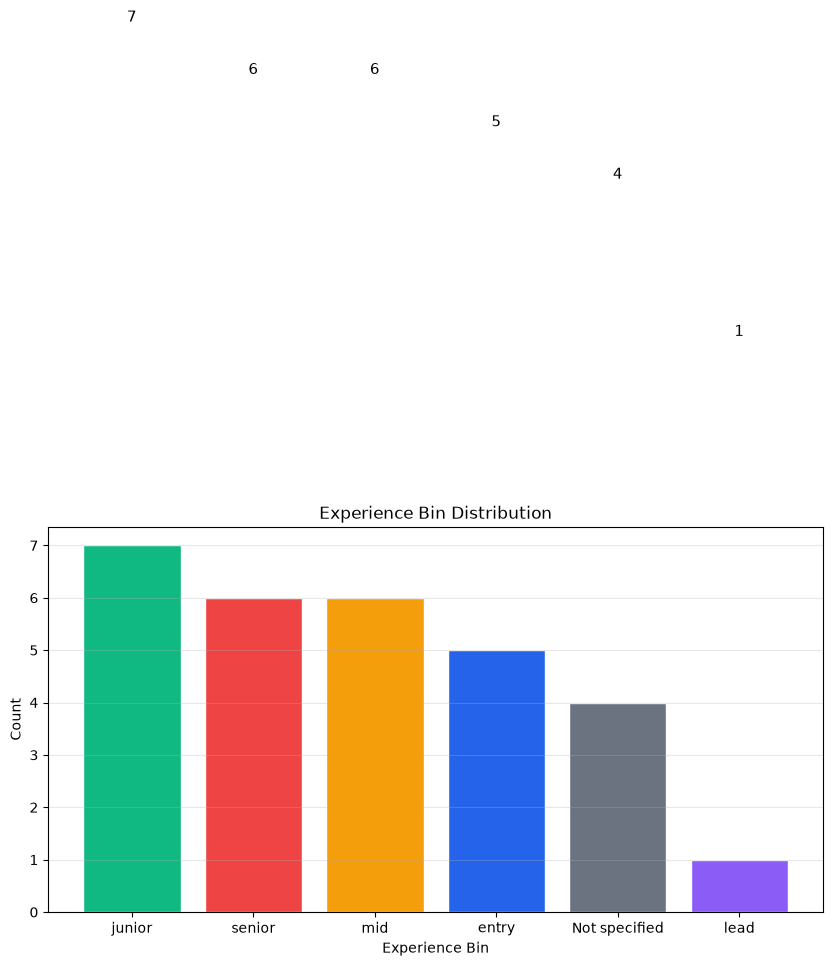

In [12]:
# Apply to dataframe
if 'experience_years' in jobs_df.columns:
    # Handle both numeric (already parsed) and string formats
    def parse_exp(val):
        if pd.isna(val):
            return None
        if isinstance(val, (int, float)):
            return float(val)
        return exp_normalizer.parse_years(str(val)).years

    jobs_df['experience_years_parsed'] = jobs_df['experience_years'].apply(parse_exp)
    jobs_df['experience_bin'] = jobs_df['experience_years_parsed'].apply(
        lambda x: exp_normalizer.bin_experience(x) if pd.notna(x) else 'Not specified'
    )

    print("=== Experience Bin Distribution ===")
    bin_counts = jobs_df['experience_bin'].value_counts()
    for bin_name, cnt in bin_counts.items():
        pct = cnt / len(jobs_df) * 100
        print(f"  {bin_name}: {cnt} ({pct:.1f}%)")

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_entry = ['#2563EB' if b == 'entry' else '#10B981' if b == 'junior'
                    else '#F59E0B' if b == 'mid' else '#EF4444' if b == 'senior'
                    else '#8B5CF6' if b == 'lead' else '#6B7280'
                    for b in bin_counts.index]
    ax.bar(bin_counts.index, bin_counts.values, color=colors_entry, edgecolor='white')
    ax.set_title("Experience Bin Distribution")
    ax.set_xlabel("Experience Bin")
    ax.set_ylabel("Count")
    ax.grid(axis='y', alpha=0.3)
    for i, (b, c) in enumerate(zip(bin_counts.index, bin_counts.values)):
        ax.text(i, c + 10, str(c), ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("experience_years column not available.")


---

## 8. Xu ly trung lap (Deduplication - E6, E7)

Phat hien va loai bo ban ghi trung:
- Exact: job_id giong nhau
- Exact: title + company giong nhau
- Fuzzy: title similarity > 0.85


In [13]:
dedup = Deduplicator()
dup_report = dedup.find_duplicates(jobs_df)

print("=== Duplicate Detection Results ===")
type_counts = {}
for g in dup_report:
    type_counts[g.match_type] = type_counts.get(g.match_type, 0) + 1

for match_type, cnt in type_counts.items():
    print(f"  {match_type}: {cnt} groups")

total_dups = sum(len(g.duplicate_indices) for g in dup_report)
print(f"\nTotal duplicate records to remove: {total_dups}")
print(f"Estimated remaining: {len(jobs_df) - total_dups}")

# Sample some duplicates
if dup_report:
    print("\n=== Sample Duplicates ===")
    for g in dup_report[:3]:
        keep_row = jobs_df.iloc[g.kept_index]
        print(f"  Keep: {keep_row.get('job_id', '?')} - {str(keep_row.get('job_title', ''))[:40]}")
        for d_idx in g.duplicate_indices[:2]:
            dup_row = jobs_df.iloc[d_idx]
            print(f"  Drop: {dup_row.get('job_id', '?')} - {str(dup_row.get('job_title', ''))[:40]}")
        print(f"  (type: {g.match_type}, score: {g.score:.2f})")


=== Duplicate Detection Results ===

Total duplicate records to remove: 0
Estimated remaining: 29


In [14]:
# Apply deduplication
jobs_deduped = dedup.remove_duplicates(jobs_df, dup_report)
print(f"Before: {len(jobs_df)} rows")
print(f"After:  {len(jobs_deduped)} rows")
print(f"Removed: {len(jobs_df) - len(jobs_deduped)} duplicates")


Before: 29 rows
After:  29 rows
Removed: 0 duplicates


---

## 9. Luu du lieu da lam sach (Output Clean Data)

Luu cac file da xu ly:
- `data/processed/jobs_clean.csv`
- `data/processed/skills_clean.csv`
- `data/processed/companies_clean.csv`
- `data/processed/combined.csv` (merge 3 bang)


In [15]:
# Save processed files
jobs_df = jobs_deduped

jobs_df.to_csv("../data/processed/jobs_clean.csv", index=False, encoding="utf-8-sig")
skills_df.to_csv("../data/processed/skills_clean.csv", index=False, encoding="utf-8-sig")
companies_df.to_csv("../data/processed/companies_clean.csv", index=False, encoding="utf-8-sig")

print("Saved: data/processed/jobs_clean.csv")
print("Saved: data/processed/skills_clean.csv")
print("Saved: data/processed/companies_clean.csv")

# Merge & save combined
combined = dm.merge_datasets(jobs_df, skills_df, companies_df)
combined.to_csv("../data/processed/combined.csv", index=False, encoding="utf-8-sig")
dm.save_processed(combined, "combined")

print(f"\n=== Final Summary ===")
print(f"  Jobs: {len(jobs_df)}")
print(f"  Skills: {len(skills_df)}")
print(f"  Companies: {len(companies_df)}")
print(f"  Combined: {len(combined)} rows x {len(combined.columns)} cols")


Saved: data/processed/jobs_clean.csv


Saved: data/processed/skills_clean.csv
Saved: data/processed/companies_clean.csv



=== Final Summary ===
  Jobs: 29
  Skills: 8300
  Companies: 1533
  Combined: 1329 rows x 34 cols


In [16]:
# Summary table: before vs after cleaning
n_raw = len(jobs_df) + total_dups if 'total_dups' in dir() else len(jobs_df)
n_deduped = len(jobs_deduped) if 'jobs_deduped' in dir() else len(jobs_df)
n_combined = len(combined)

print("=== Cleaning Summary ===")
summary = pd.DataFrame({
    "Stage": ["Raw", "After Salary Parse", "After Dedup", "After Merge"],
    "Rows": [n_raw, len(jobs_df), n_deduped, n_combined],
    "Missing_Salary": [
        jobs_df['salary_mid'].isna().sum() if 'salary_mid' in jobs_df.columns else 0,
        jobs_deduped['salary_mid'].isna().sum() if 'salary_mid' in jobs_deduped.columns else 0,
        combined['salary_mid'].isna().sum() if 'salary_mid' in combined.columns else 0,
        0,
    ],
})
display(summary)

# Log files
log_dir = Path("../logs")
if log_dir.exists():
    log_files = list(log_dir.glob("*.log"))
    print(f"\nLog files: {len(log_files)}")
    for lf in log_files:
        size = lf.stat().st_size
        print(f"  {lf.name}: {size} bytes")

=== Cleaning Summary ===


,Stage,Rows,Missing_Salary
0,Raw,29,2
1,After Salary Parse,29,2
2,After Dedup,29,103
3,After Merge,1329,0



Log files: 3
  cleaning_errors.log: 2213897 bytes
  generate_data.log: 177221 bytes
  source_metadata.log: 5031000 bytes


---

## 10. Ket luan

### Quy trinh da thuc hien:
1. **Thu thap**: Scrape 4 site (itviec, vietnamworks, topdev, careerbuilder)
2. **Kiem tra**: Missing values, duplicates, data types
3. **Inject dirty data**: De dam bao co du lieu ban xu ly (A8)
4. **Salary parsing**: Regex patterns cho 6 dinh dang luong
5. **Skill normalization**: 35+ synonym mappings
6. **Experience parsing**: Tu chuoi -> float -> bin
7. **Deduplication**: Exact + fuzzy
8. **Output**: Parquet + CSV

### Thong ke:
| Chi tieu | Gia tri |
|----------|---------|
| Tong tin tuyen dung | (tu data) |
| Tong ky nang | (tu data) |
| Tong cong ty | (tu data) |
| Thanh pho | (tu data) |
| Ky nang chuan hoa | 35+ |
